# Regional Multi-Horizon LSTM Models

This notebook trains one LSTM per region for temporal generalization. Each model uses a 24-hour input window ending at prediction time `t` and predicts carbon intensity at `t+1`, `t+6`, and `t+24`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="whitegrid")

TARGET_COL = "carbon_intensity"
UNIT = "gCO2eq/kWh"
HORIZONS = [1, 6, 24]
REGIONS = ["california", "illinois", "texas", "virginia"]
TRAIN_FRAC = 0.70
VAL_FRAC = 0.10
VAL_END_FRAC = TRAIN_FRAC + VAL_FRAC
PREDICTION_DIR = Path("model_predictions")
PREDICTION_DIR.mkdir(exist_ok=True)

CONFIG = {
    "window_size": 24,
    "lstm_units": 64,
    "num_layers": 1,
    "dropout": 0.2,
    "epochs": 150,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "patience": 20,
    "seed": 42,
}

feature_cols = [
    "temp_c", "wind_speed", "cloud_cover", "solar_radiation",
    "carbon_intensity_lag_1", "carbon_intensity_lag_2",
    "carbon_intensity_lag_3", "carbon_intensity_lag_24",
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos",
    "cfe_pct", "re_pct",
]

required_prediction_columns = [
    "datetime", "target_datetime", "region", "horizon", "model",
    "y_true", "y_pred", "split_type", "split", "holdout_region",
]

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: mps


In [2]:
df = pd.read_csv("full_dataset_featured.csv", parse_dates=["datetime"])
df = df.sort_values(["region", "datetime"]).reset_index(drop=True)
print("Shape:", df.shape)
display(df.head())


Shape: (34944, 22)


,datetime,carbon_intensity,cfe_pct,re_pct,region,temp_c,wind_speed,cloud_cover,solar_radiation,hour,...,carbon_intensity_lag_1,carbon_intensity_lag_2,carbon_intensity_lag_3,carbon_intensity_lag_24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2023-01-02 00:00:00,189.75,57.76,42.56,california,13.8,15.7,62,214.0,0,...,147.89,124.07,122.53,214.40,0.000000,1.000000,0.0,1.0,0.5,0.866025
1,2023-01-02 01:00:00,207.79,53.13,38.72,california,11.4,12.8,19,54.0,1,...,189.75,147.89,124.07,216.88,0.258819,0.965926,0.0,1.0,0.5,0.866025
2,2023-01-02 02:00:00,213.71,52.04,37.98,california,9.6,10.7,57,0.0,2,...,207.79,189.75,147.89,220.01,0.500000,0.866025,0.0,1.0,0.5,0.866025
3,2023-01-02 03:00:00,214.20,52.12,37.95,california,7.9,8.2,58,0.0,3,...,213.71,207.79,189.75,225.41,0.707107,0.707107,0.0,1.0,0.5,0.866025
4,2023-01-02 04:00:00,216.54,52.20,37.62,california,7.3,6.9,99,0.0,4,...,214.20,213.71,207.79,220.87,0.866025,0.500000,0.0,1.0,0.5,0.866025


## Sequence Helpers

`datetime` in exported rows is the end of the 24-hour input window. `target_datetime` is exactly `datetime + horizon hours`.


In [3]:
def sequence_indices(n, window_size, max_horizon):
    for start in range(0, n - window_size - max_horizon + 1):
        end = start + window_size - 1
        target_indices = [end + h for h in HORIZONS]
        yield start, end, target_indices


def split_for_end_index(end_idx, n, max_horizon):
    train_boundary = int(n * TRAIN_FRAC)
    val_boundary = int(n * VAL_END_FRAC)
    train_end = max(train_boundary - max_horizon, 0)
    val_end = max(val_boundary - max_horizon, train_boundary)

    if end_idx < train_end:
        return "train"
    if train_boundary <= end_idx < val_end:
        return "val"
    if end_idx >= val_boundary:
        return "test"
    return "unused_gap"


def build_region_sequences(group, feature_scaler=None, target_scaler=None):
    group = group.sort_values("datetime").reset_index(drop=True)
    n = len(group)
    W = CONFIG["window_size"]
    max_horizon = max(HORIZONS)

    train_boundary = int(n * TRAIN_FRAC)
    train_feature_rows = group.iloc[: max(train_boundary - max_horizon, 1)]

    if feature_scaler is None:
        feature_scaler = MinMaxScaler().fit(train_feature_rows[feature_cols])
    if target_scaler is None:
        target_scaler = MinMaxScaler().fit(group.iloc[:train_boundary][[TARGET_COL]])

    X_scaled = feature_scaler.transform(group[feature_cols])
    y_scaled = target_scaler.transform(group[[TARGET_COL]]).reshape(-1)

    buckets = {"train": [], "val": [], "test": []}
    metadata = {"train": [], "val": [], "test": []}

    for start, end, target_indices in sequence_indices(n, W, max_horizon):
        split = split_for_end_index(end, n, max_horizon)
        if split not in buckets:
            continue
        buckets[split].append((X_scaled[start : end + 1], y_scaled[target_indices]))
        metadata[split].append({
            "datetime": group.loc[end, "datetime"],
            "target_datetimes": [group.loc[i, "datetime"] for i in target_indices],
            "region": group.loc[end, "region"],
        })

    arrays = {}
    for split, rows in buckets.items():
        if rows:
            X = np.stack([r[0] for r in rows]).astype(np.float32)
            y = np.stack([r[1] for r in rows]).astype(np.float32)
        else:
            X = np.empty((0, W, len(feature_cols)), dtype=np.float32)
            y = np.empty((0, len(HORIZONS)), dtype=np.float32)
        arrays[split] = (X, y, metadata[split])

    return arrays, feature_scaler, target_scaler


In [4]:
class CarbonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MultiHorizonLSTM(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout, n_outputs):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, n_outputs)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


def train_model(X_train, y_train, X_val, y_val, save_path):
    train_loader = DataLoader(CarbonDataset(X_train, y_train), batch_size=CONFIG["batch_size"], shuffle=False)
    val_loader = DataLoader(CarbonDataset(X_val, y_val), batch_size=CONFIG["batch_size"], shuffle=False)

    model = MultiHorizonLSTM(
        n_features=X_train.shape[2],
        hidden_size=CONFIG["lstm_units"],
        num_layers=CONFIG["num_layers"],
        dropout=CONFIG["dropout"],
        n_outputs=len(HORIZONS),
    ).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

    best_val_loss = float("inf")
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(CONFIG["epochs"]):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = float(np.mean(batch_losses))

        model.eval()
        batch_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                batch_losses.append(criterion(model(X_batch), y_batch).item())
        val_loss = float(np.mean(batch_losses))
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["patience"]:
                print(f"Early stopping at epoch {epoch + 1}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    model.load_state_dict(torch.load(save_path, map_location=device))
    return model, train_losses, val_losses


## Train Regional LSTMs And Export Temporal Predictions


In [5]:
all_predictions = []
region_losses = {}
region_models = {}

for region, group in df.groupby("region"):
    print("\nRegion:", region)
    arrays, feature_scaler, target_scaler = build_region_sequences(group)
    X_train, y_train, _ = arrays["train"]
    X_val, y_val, _ = arrays["val"]
    X_test, y_test, test_meta = arrays["test"]
    print("train", X_train.shape, "val", X_val.shape, "test", X_test.shape)

    model, train_losses, val_losses = train_model(
        X_train,
        y_train,
        X_val,
        y_val,
        save_path=f"best_lstm_regional_{region}.pt",
    )
    region_models[region] = model
    region_losses[region] = (train_losses, val_losses)

    model.eval()
    with torch.no_grad():
        preds_scaled = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy()

    y_pred = target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(-1, len(HORIZONS))
    y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, len(HORIZONS))

    for row_idx, meta in enumerate(test_meta):
        for h_idx, horizon in enumerate(HORIZONS):
            all_predictions.append({
                "datetime": meta["datetime"],
                "target_datetime": meta["target_datetimes"][h_idx],
                "region": meta["region"],
                "horizon": horizon,
                "model": "lstm_regional",
                "y_true": y_true[row_idx, h_idx],
                "y_pred": y_pred[row_idx, h_idx],
                "split_type": "chronological_time",
                "split": "test",
                "holdout_region": "none",
            })

predictions_df = pd.DataFrame(all_predictions)[required_prediction_columns]
output_path = PREDICTION_DIR / "lstm_regional_predictions.csv"
predictions_df.to_csv(output_path, index=False)
print(f"Saved {len(predictions_df):,} predictions to {output_path}")
display(predictions_df.head())



Region: california


train (6068, 24, 16) val (849, 24, 16) test (1724, 24, 16)


Epoch  10 | Train: 0.0088 | Val: 0.0118


Epoch  20 | Train: 0.0067 | Val: 0.0091


Epoch  30 | Train: 0.0057 | Val: 0.0086


...

Epoch  60 | Train: 0.0047 | Val: 0.0085


Epoch  70 | Train: 0.0043 | Val: 0.0091


Early stopping at epoch 77


Saved 20,688 predictions to model_predictions/lstm_regional_predictions.csv


,datetime,target_datetime,region,horizon,model,y_true,y_pred,split_type,split,holdout_region
0,2023-10-20 04:00:00,2023-10-20 05:00:00,california,1,lstm_regional,309.639984,293.515594,chronological_time,test,none
1,2023-10-20 04:00:00,2023-10-20 10:00:00,california,6,lstm_regional,314.179993,306.146545,chronological_time,test,none
2,2023-10-20 04:00:00,2023-10-21 04:00:00,california,24,lstm_regional,277.779999,269.841400,chronological_time,test,none
3,2023-10-20 05:00:00,2023-10-20 06:00:00,california,1,lstm_regional,310.529999,292.979919,chronological_time,test,none
4,2023-10-20 05:00:00,2023-10-20 11:00:00,california,6,lstm_regional,312.459991,305.160980,chronological_time,test,none


## Regional LSTM Diagnostics


,region,horizon,MAE,RMSE,R2,Bias
0,california,1,15.593024,18.681554,0.893554,-13.888843
1,california,6,20.484932,25.640944,0.798364,-8.588724
2,california,24,27.080149,33.095259,0.662622,-20.346949
3,illinois,1,7.388410,9.339642,0.966499,0.210837
4,illinois,6,24.605770,30.899495,0.631702,5.993880
5,illinois,24,48.452591,58.552771,-0.336720,23.203861
6,texas,1,20.020451,25.990442,0.891217,-16.318352
7,texas,6,46.847099,59.600485,0.428912,-16.419176
8,texas,24,58.057869,70.518881,0.199015,-8.049202
9,virginia,1,4.503722,5.703321,0.929204,-0.483951


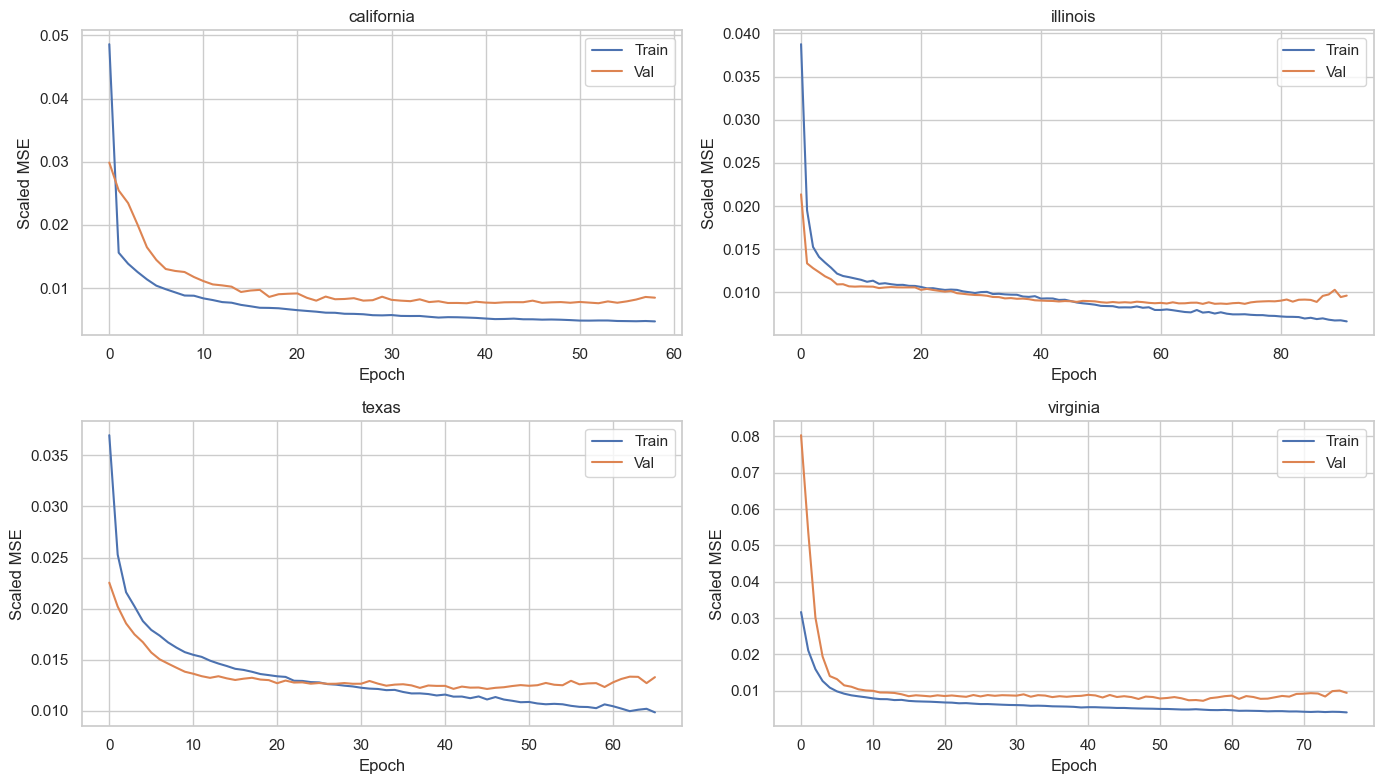

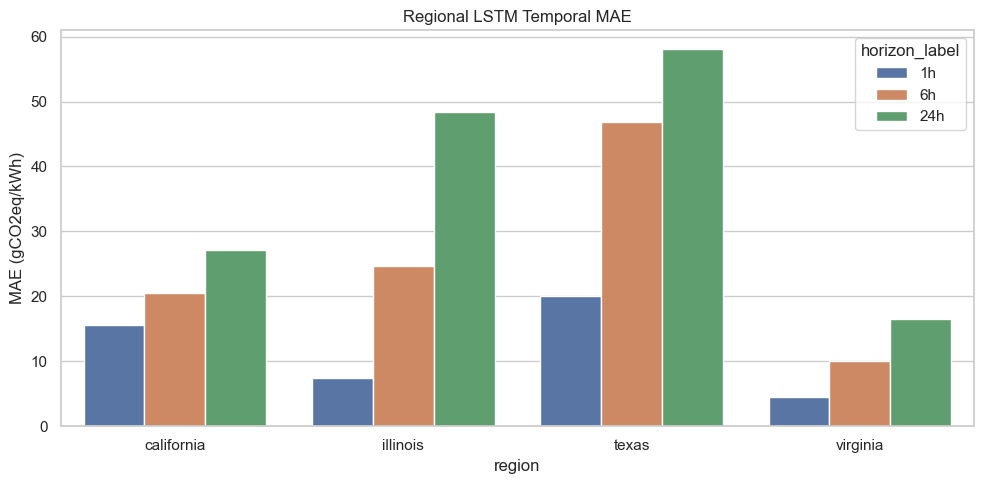

In [6]:
def metric_row(y_true, y_pred):
    residual = np.asarray(y_pred) - np.asarray(y_true)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias": float(np.mean(residual)),
    }

rows = []
for keys, group in predictions_df.groupby(["region", "horizon"]):
    row = dict(zip(["region", "horizon"], keys))
    row.update(metric_row(group["y_true"], group["y_pred"]))
    rows.append(row)
metrics_df = pd.DataFrame(rows)
display(metrics_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (region, losses) in zip(axes.flat, region_losses.items()):
    train_losses, val_losses = losses
    ax.plot(train_losses, label="Train")
    ax.plot(val_losses, label="Val")
    ax.set_title(region)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Scaled MSE")
    ax.legend()
plt.tight_layout()
plt.show()

metrics_df["horizon_label"] = metrics_df["horizon"].astype(str) + "h"
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x="region", y="MAE", hue="horizon_label")
plt.title("Regional LSTM Temporal MAE")
plt.ylabel(f"MAE ({UNIT})")
plt.tight_layout()
plt.show()
